### Задание

Провести предобработку датасета о **Бейсбольных игроках** и построить кластеризатор (иерархический и статистический[ЕМ-алгоритм] ). А также визуализировать результаты на дендрограмме и с помощью PCA (Задания 1 - 10)

Задачи 11-12 состоят в том, чтобы с использованием методов обучения без учителя построить одноклассовую модель на основе поиска аномалий, которая максимально хорошо отфильтрует шестерки (как аномалии) от нулей (как основной выборки). Использовать KernelPCA и визуализиовать результаты.

In [40]:
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import KernelPCA
from sklearn.metrics import roc_curve, auc, roc_auc_score

from varclushi import VarClusHi

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(123)

### Задание 1
В файле «baseball.csv» находится выборка с информацией по игрокам в бейсбол, включая
статистику их результативности, время участия в играх, лига, зарплата и т.д. Name (имя) нужно
считать идентификатором записи. Загрузите этот файл и произведите следующие действия для
кластерного анализа.

In [2]:
data_start = pd.read_csv('baseball.csv')
data = data_start.drop(columns=['Name'])
data

,Team,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,...,CrBB,League,Division,Position,nOuts,nAssts,nError,Salary,Div,logSalary
0,Cleveland,293,66,1,30,29,14,1,293,66,...,14,American,East,C,446,33,20,NaN,AE,NaN
1,Houston,315,81,7,24,38,39,14,3449,835,...,375,National,West,C,632,43,10,475.0,NW,6.163315
2,Seattle,479,130,18,66,72,76,3,1624,457,...,263,American,West,1B,880,82,14,480.0,AW,6.173786
3,Montreal,496,141,20,65,78,37,11,5628,1575,...,354,National,East,RF,200,11,3,500.0,NE,6.214608
4,Montreal,321,87,10,39,42,30,2,396,101,...,33,National,East,1B,805,40,4,91.5,NE,4.516339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,St Louis,497,127,7,65,48,37,5,2703,806,...,138,National,East,CF,325,9,3,700.0,NE,6.551080
318,New York,492,136,5,76,50,94,12,5511,1511,...,875,American,East,2B,313,381,20,875.0,AE,6.774224
319,Chicago,475,126,3,61,43,52,6,1700,433,...,146,American,West,3B,37,113,7,385.0,AW,5.953243
320,Toronto,573,144,9,85,60,78,8,3198,857,...,332,American,East,1B,1314,131,12,960.0,AE,6.866933


### Задание 2. 
Обработка пропусков. Переменная Salary (и log Salary) может содержать пропуски,
произведите подстановку пропусков методом согласно вашему варианту. Пересчитайте
logSalary как log(1+Salary), чтобы получить более симметричное распределение

In [3]:
data.Salary = KNNImputer(n_neighbors=5).fit_transform(data[['Salary']].values)
data.logSalary = np.log(1+data.Salary)
data.Salary, data.logSalary

(0       535.925882
 1       475.000000
 2       480.000000
 3       500.000000
 4        91.500000
           ...     
 317     700.000000
 318     875.000000
 319     385.000000
 320     960.000000
 321    1000.000000
 Name: Salary, Length: 322, dtype: float64,
 0      6.285860
 1      6.165418
 2      6.175867
 3      6.216606
 4      4.527209
          ...   
 317    6.552508
 318    6.775366
 319    5.955837
 320    6.867974
 321    6.908755
 Name: logSalary, Length: 322, dtype: float64)

### Задание 3. 
Нормализация переменных – приведите числовые переменные к близким шкалам с помощью
методов для вашего варианта и закодируйте категориальные с помощью OneHotEncoder.

In [4]:
col_columns = data.select_dtypes([int, float]).columns
data[col_columns] = MaxAbsScaler().fit_transform(data[col_columns])
data.head()

,Team,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,...,CrBB,League,Division,Position,nOuts,nAssts,nError,Salary,Div,logSalary
0,Cleveland,0.426492,0.277311,0.025,0.230769,0.239669,0.133333,0.041667,0.020850,0.015508,...,0.008940,American,East,C,0.323657,0.067073,0.62500,0.217856,AE,0.805020
1,Houston,0.458515,0.340336,0.175,0.184615,0.314050,0.371429,0.583333,0.245428,0.196194,...,0.239464,National,West,C,0.458636,0.087398,0.31250,0.193089,NW,0.789596
2,Seattle,0.697234,0.546218,0.450,0.507692,0.595041,0.723810,0.125000,0.115563,0.107378,...,0.167944,American,West,1B,0.638607,0.166667,0.43750,0.195122,AW,0.790934
3,Montreal,0.721980,0.592437,0.500,0.500000,0.644628,0.352381,0.458333,0.400484,0.370066,...,0.226054,National,East,RF,0.145138,0.022358,0.09375,0.203252,NE,0.796151
4,Montreal,0.467249,0.365546,0.250,0.300000,0.347107,0.285714,0.083333,0.028179,0.023731,...,0.021073,National,East,1B,0.584180,0.081301,0.12500,0.037195,NE,0.579793


### Задание 4. 
С помощью восходящей иерархической кластеризации с выбранными параметрами
расстояния согласно вашему варианту постройте кластерную модель данных и дендрограмму
для топ 20 кластеров.

In [5]:
cat_columns = data.select_dtypes(['object']).columns

enc = OneHotEncoder()
transformed_columns = enc.fit_transform(data[cat_columns]).toarray()

data = data.join( pd.DataFrame(transformed_columns, columns=enc.get_feature_names_out()) )
data.drop(columns=cat_columns, inplace=True)
data.head()

,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,CrHome,...,Position_OF,Position_OS,Position_RF,Position_S3,Position_SS,Position_UT,Div_AE,Div_AW,Div_NE,Div_NW
0,0.426492,0.277311,0.025,0.230769,0.239669,0.133333,0.041667,0.020850,0.015508,0.001825,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.458515,0.340336,0.175,0.184615,0.314050,0.371429,0.583333,0.245428,0.196194,0.125912,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.697234,0.546218,0.450,0.507692,0.595041,0.723810,0.125000,0.115563,0.107378,0.114964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.721980,0.592437,0.500,0.500000,0.644628,0.352381,0.458333,0.400484,0.370066,0.410584,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.467249,0.365546,0.250,0.300000,0.347107,0.285714,0.083333,0.028179,0.023731,0.021898,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
clusterer = AgglomerativeClustering(n_clusters=20, linkage='average', metric='euclidean')
clust_data = clusterer.fit_predict(data)
print(clust_data.shape)
# plt.scatter(data.iloc[:, 3], data.iloc[:, 6], c=clust_data)
clust_data

(322,)


array([ 7,  2, 10,  6,  0, 16,  0,  1,  2,  5,  3,  2,  0,  7,  0,  1, 14,
        1,  4,  2,  0,  1,  1,  2, 12,  7,  0,  2,  2,  1,  8,  2, 13,  3,
        1, 14,  3,  2,  5,  2,  7, 17,  2,  7,  7,  7,  2,  7, 12,  2,  1,
        0,  5, 18,  5,  2,  2,  7,  2,  3,  7,  9,  8,  2,  4,  5,  0,  1,
        3,  7, 17,  0, 18, 12,  5,  3,  2,  0,  1,  4, 15,  9, 12,  1,  2,
        4, 14,  5,  8, 16,  1,  6,  3,  1,  2, 14,  5,  2,  2,  2, 12,  3,
        3,  7,  5,  7,  2,  1,  5,  7, 18,  2,  6, 13,  9, 18, 16,  4,  2,
        7,  9, 14,  1,  0,  2, 15,  1,  1,  6,  1,  0,  0, 15,  8,  2,  0,
        5,  7,  7,  1,  1,  7,  0, 14,  8,  6,  7,  3,  3,  5,  1,  1,  2,
        2,  0,  1,  9,  0, 15, 18,  1,  0,  1,  5, 17,  0,  0,  7,  1,  0,
        1,  7,  2,  1,  2,  2,  2,  5,  5,  6, 10,  2,  2,  0,  6, 14, 15,
        1,  2,  6,  0,  7,  7,  2,  5,  7, 15,  0,  7,  1,  3,  2,  3,  0,
        1,  0,  2,  5,  0,  7,  1,  0,  1,  0,  2,  3,  1, 19,  2,  1,  0,
        0,  0,  2,  7,  2

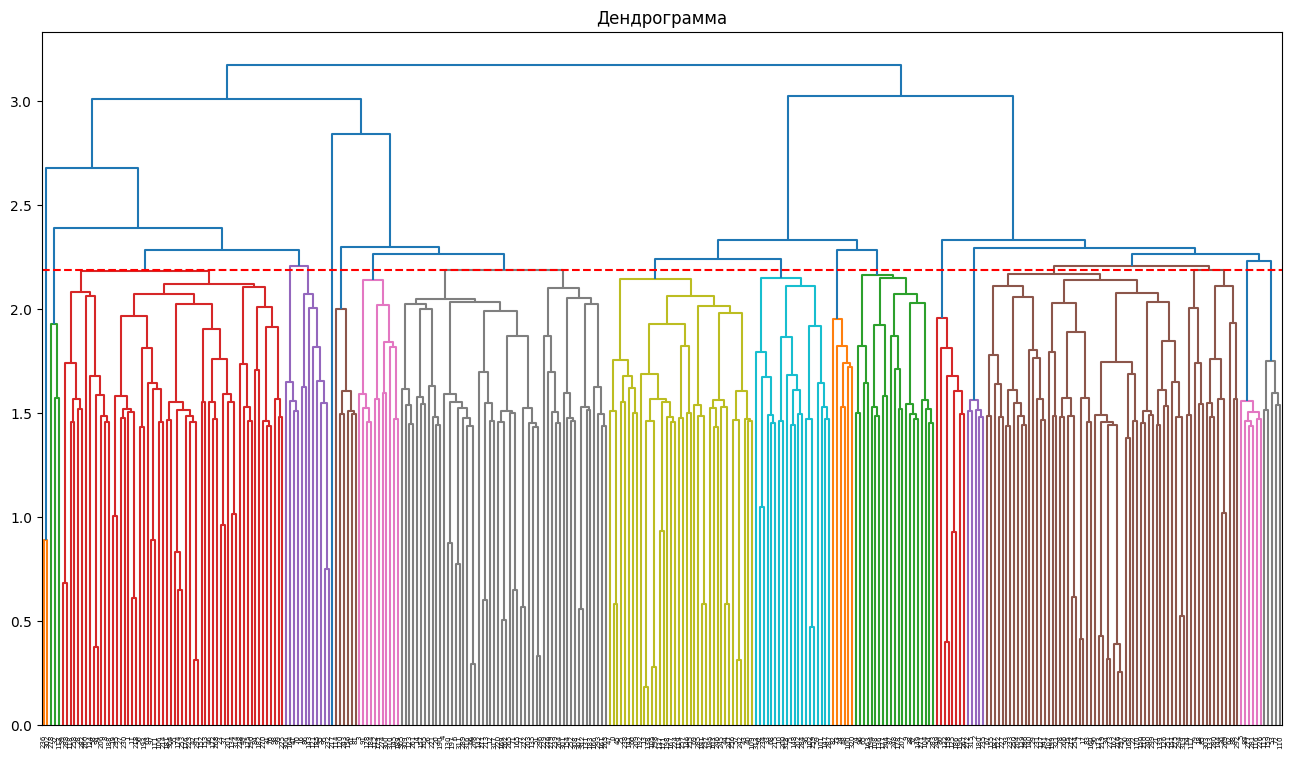

In [7]:
Z = linkage(data, method='average', metric='euclidean')

plt.figure(figsize=(16, 9))
plt.title('Дендрограмма')
dendrogram(Z)
plt.axhline(y=Z[-20][2], color='r', linestyle='--')
plt.show()

### Задание 5. 
Рассчитайте значение критерия pseudoF для вариантов кластеризации 2-20 кластеров,
постройте график зависимости критерия от числа кластеров и выберите оптимальное (первый
локальный пик критерия при обходе от малого числа кластеров к большому). Отметьте точку
на графике. Сколько кластеров получилось?

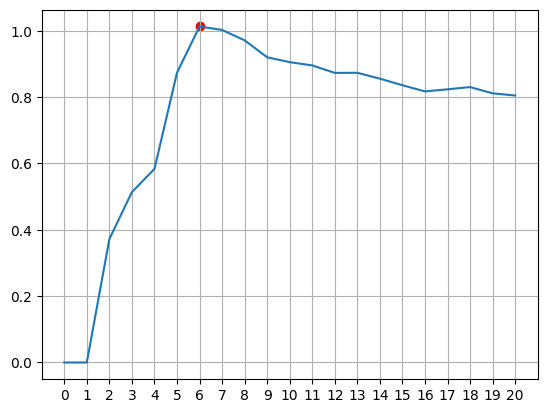

In [8]:
def calc_pseudoF(data, clust_data, k):
    mu_data = data.mean()
    
    TSS = data.apply(lambda x: np.linalg.norm(x - mu_data)**2, axis=1).sum()
    BSS = 0
    for c in set(clust_data):
        mu_cluster = data[clust_data == c].mean()
        BSS += np.linalg.norm(mu_data - mu_cluster) ** 2

    return BSS/(TSS-BSS) * (data.shape[0] - k)/(k - 1)

history = [0, 0]
first_peak = None
for k in range(2, 21):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='average', metric='euclidean')
    clustered_data = clusterer.fit_predict(data)
    history.append(calc_pseudoF(data, clustered_data, k))
    if first_peak is None and history[-2] > history[-1] and history[-2] > history[-3]:
        first_peak = (k-1, history[-2])

plt.xticks(range(21))
plt.grid(True)
plt.plot(range(21), history)
plt.scatter(first_peak[0], first_peak[1], c='r')
plt.show()

> Т.е. 6 кластеров - это самое оптимальное кол-во! Что также можно наблюдать и на дендрограмме!

In [9]:
AC_clusterer = AgglomerativeClustering(n_clusters=6, linkage='average', metric='euclidean')
AC_clustered_data = AC_clusterer.fit_predict(data)

### Задание 6. 
С помощью метода проекции для вашего варианта постройте отображение на плоскость,
цветом точки укажите номер кластера.

<BarContainer object of 75 artists>

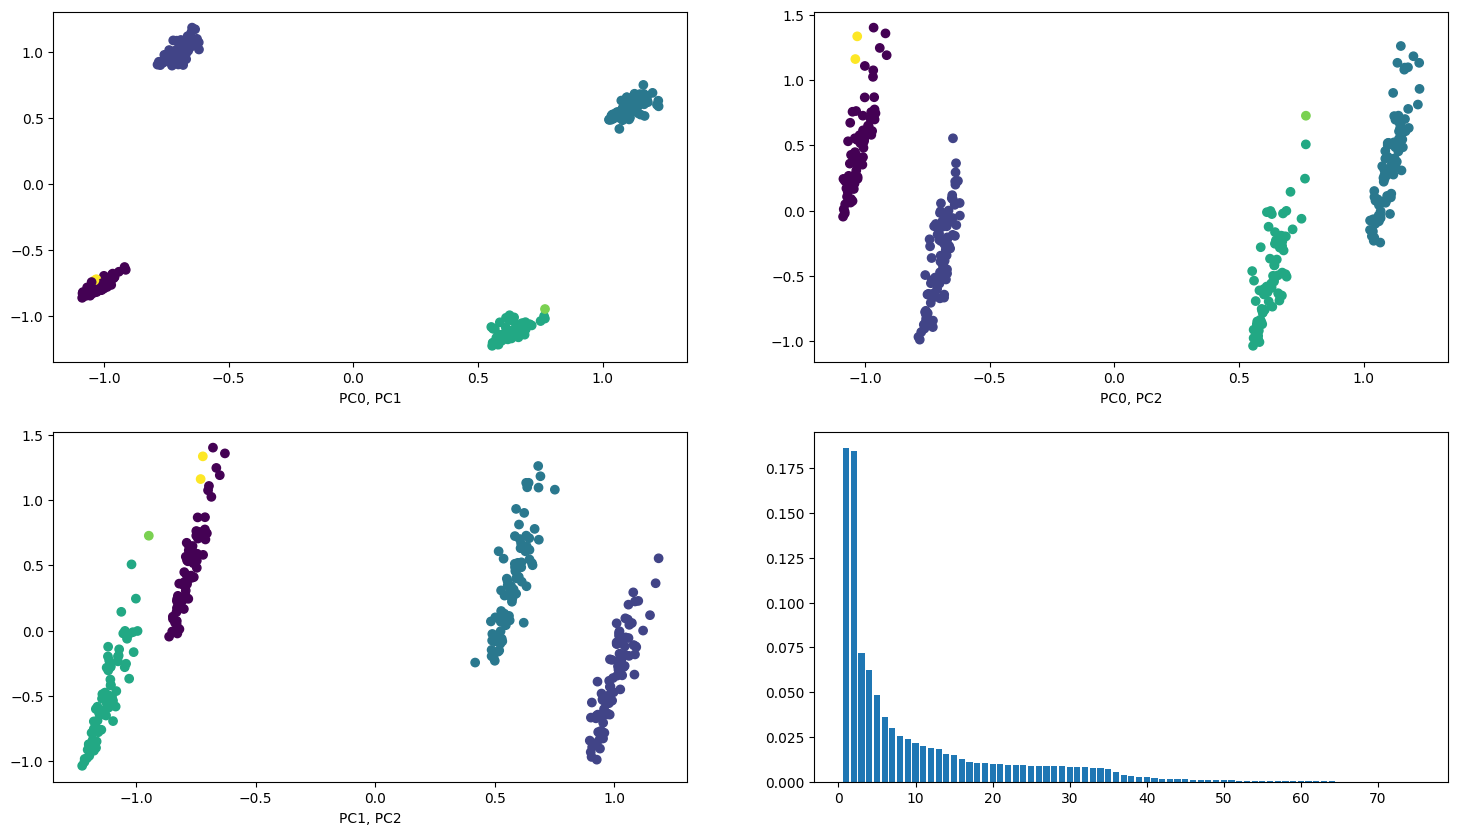

In [10]:
pca = PCA()
pca_features = pca.fit_transform(data)

_, axs = plt.subplots(2, 2, figsize=(18, 10))

axs[0][0].set_xlabel(f'PC{0}, PC{1}')
axs[0][0].scatter(pca_features.T[0], pca_features.T[1], c=AC_clustered_data)
axs[0][1].set_xlabel(f'PC{0}, PC{2}')
axs[0][1].scatter(pca_features.T[0], pca_features.T[2], c=AC_clustered_data)
axs[1][0].set_xlabel(f'PC{1}, PC{2}')
axs[1][0].scatter(pca_features.T[1], pca_features.T[2], c=AC_clustered_data)

axs[1][1].bar(range(1, 76), pca.explained_variance_ratio_)


### Задание 7. 
Выполните кластеризацию сферическими кластерами с прототипом методом из вашего
варианта, также постройте проекцию как на шаге 6, определите наиболее типичного
представителя (по имени) в каждом из кластеров.

> У меня EM-Алгоритм

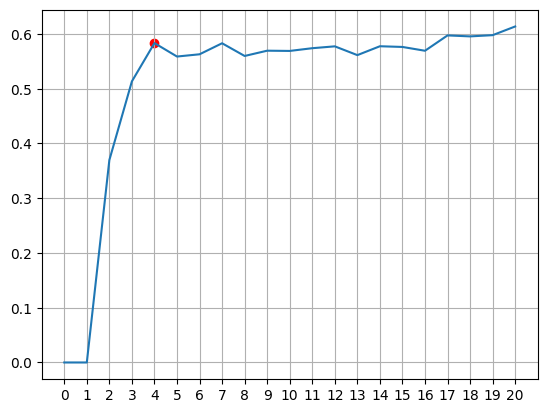

In [11]:
history = [0, 0]
first_peak = None
for k in range(2, 21):
    clusterer = GaussianMixture(n_components=k)
    clustered_data = clusterer.fit_predict(data)
    history.append(calc_pseudoF(data, clustered_data, k))
    if first_peak is None and history[-2] > history[-1] and history[-2] > history[-3]:
        first_peak = (k-1, history[-2])

plt.xticks(range(21))
plt.grid(True)
plt.plot(range(21), history)
plt.scatter(first_peak[0], first_peak[1], c='r')
plt.show()

> Т.е. 4 кластера - самое оптимальное количество

In [12]:
GM_clusterer = GaussianMixture(n_components=4)
GM_clusterer.fit(data)
GM_clustered_data = GM_clusterer.predict(data)
GM_clustered_data_proba = GM_clusterer.predict_proba(data)

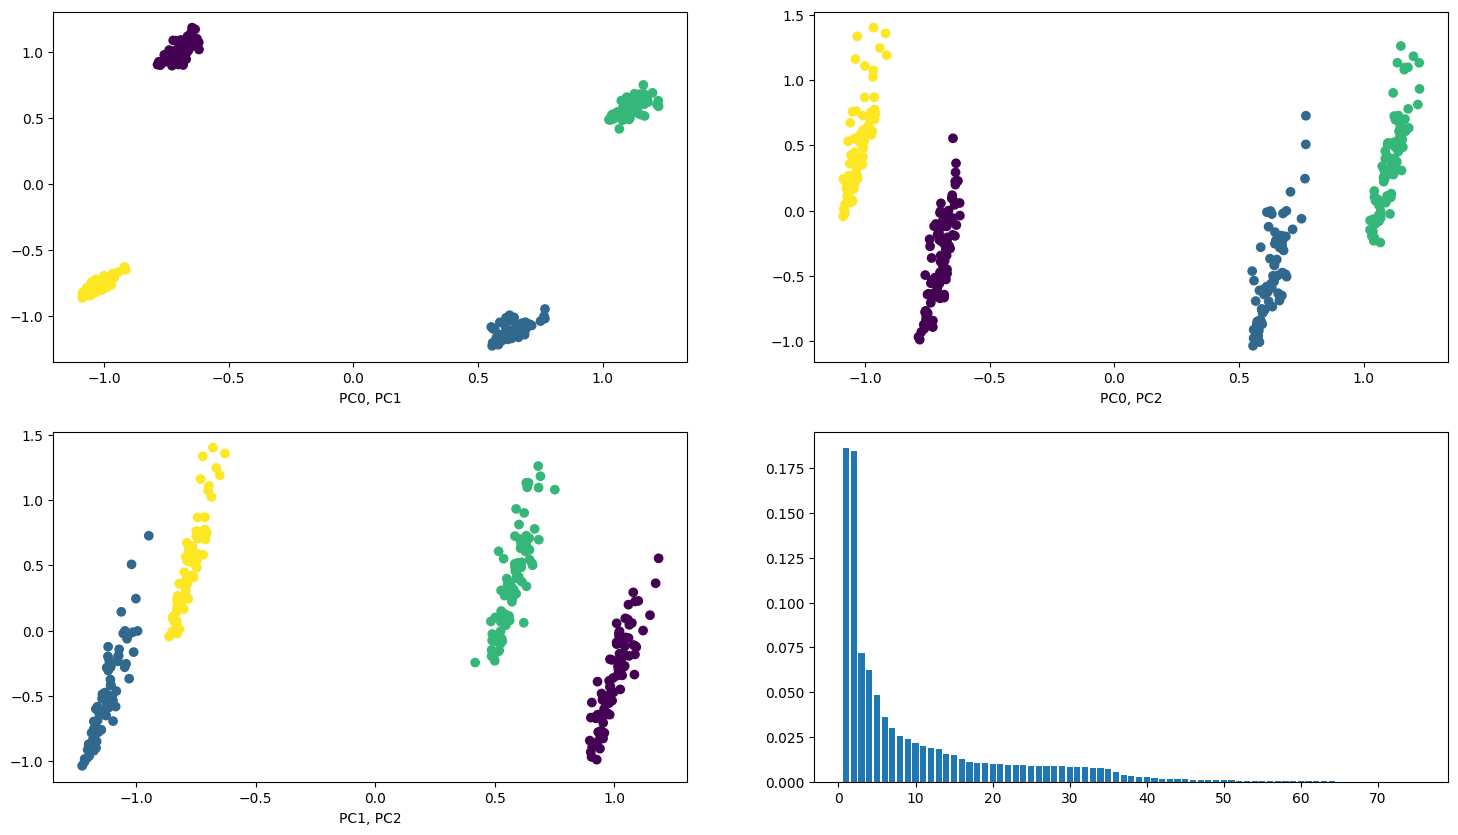

In [13]:
pca = PCA()
pca_features = pca.fit_transform(data)

_, axs = plt.subplots(2, 2, figsize=(18, 10))

axs[0][0].set_xlabel(f'PC{0}, PC{1}')
axs[0][0].scatter(pca_features.T[0], pca_features.T[1], c=GM_clustered_data)
axs[0][1].set_xlabel(f'PC{0}, PC{2}')
axs[0][1].scatter(pca_features.T[0], pca_features.T[2], c=GM_clustered_data)
axs[1][0].set_xlabel(f'PC{1}, PC{2}')
axs[1][0].scatter(pca_features.T[1], pca_features.T[2], c=GM_clustered_data)

axs[1][1].bar(range(1, 76), pca.explained_variance_ratio_)

plt.show()


In [14]:
set(GM_clustered_data_proba.reshape(322*4)) # => любой представитель класса будет лучшим, т.к. класс каждого игрока определен однозначно

{0.0, 1.0}

In [15]:
for c in range(4):
    print(f'Класс: {c}', f'Представитель: {data_start.iloc[GM_clustered_data.tolist().index(c)]['Name']}')

Класс: 0 Представитель: Davis, Alan
Класс: 1 Представитель: Dawson, Andre
Класс: 2 Представитель: Allanson, Andy
Класс: 3 Представитель: Ashby, Alan


### Задание 8. 
Реализуйте шаги 3-7 в виде функции или класса.

In [5]:
def preprocessing(data: pd.DataFrame):
    '''НОРМАЛИЗАЦИЯ числовых признаков и КОДИРОВАНИЕ категориальных'''
    X = data.copy()

    col_columns = X.select_dtypes([int, float]).columns
    cat_columns = X.select_dtypes(['object']).columns

    X[col_columns] = MaxAbsScaler().fit_transform(X[col_columns])

    enc = OneHotEncoder()
    transformed_columns = enc.fit_transform(X[cat_columns]).toarray()

    X = X.join( pd.DataFrame(transformed_columns, columns=enc.get_feature_names_out()) )
    X.drop(columns=cat_columns, inplace=True)

    return X


def hierarhy_clustering(X: pd.DataFrame, k=6):
    '''Построение иерархической модели (Аггломеративная кластеризация Ланса-Уильямса)'''

    clusterer = AgglomerativeClustering(n_clusters=k, linkage='average', metric='euclidean')

    return clusterer.fit_predict(X)


def dendrogram_building(X: pd.DataFrame, clusters_treshold=20):
    '''Отрисовка дендрограммы и порога в clusters_treshold класетров'''

    Z = linkage(X, method='average', metric='euclidean')

    plt.figure(figsize=(16, 9))
    plt.title('Дендрограмма')
    dendrogram(Z)
    plt.axhline(y=Z[-clusters_treshold][2], color='r', linestyle='--')
    plt.show()


def statistic_clustering(X: pd.DataFrame, k=4, return_proba=False):
    '''Построение статистической модели (EM-алгоритм на Гауссовых распределениях[грубая кластеризация на k-means])'''

    clusterer = GaussianMixture(n_components=k)
    clusterer.fit(X)

    if return_proba:
        return clusterer.predict(X), clusterer.predict_proba(X)
    else:
        return clusterer.predict(X)


def calc_pseudoF(X: pd.DataFrame, clusters, k):
    '''Расчет pseudoF для k кдастеров'''

    mu_data = X.mean()

    TSS = X.apply(lambda x: np.linalg.norm(x - mu_data)**2, axis=1).sum()
    BSS = 0
    for c in set(clusters):
        mu_cluster = X[clusters == c].mean()
        BSS += np.linalg.norm(mu_data - mu_cluster) ** 2

    return BSS/(TSS-BSS) * (X.shape[0] - k)/(k - 1)


def pseudoF_plot(X: pd.DataFrame, max_k=20, mode='statistic'):
    '''Построение pseudoF диаграммы для statistic или hierarhy модели. И нахождение первого пика'''

    if mode == 'statistic':
        mode_func = statistic_clustering
    elif mode == 'hierarhy':
        mode_func = hierarhy_clustering
    else:
        return 'Unknown mode'

    history = [0, 0]
    first_peak = None
    for k in range(2, max_k+1):
        clustered_data = mode_func(X, k)
        history.append(calc_pseudoF(X, clustered_data, k))
        if first_peak is None and history[-2] > history[-1] and history[-2] > history[-3]:
            first_peak = (k-1, history[-2])

    plt.xticks(range(max_k+1))
    plt.grid(True)
    plt.plot(range(max_k+1), history)
    plt.scatter(first_peak[0], first_peak[1], c='r')
    plt.show()
    
    return first_peak[0]


def pca_plot(X: pd.DataFrame, clustered_data):
    '''Иллюстрация кластеров с помощью PCA'''

    pca = PCA()
    pca_features = pca.fit_transform(X)

    _, axs = plt.subplots(2, 2, figsize=(18, 10))

    axs[0][0].set_xlabel(f'PC{0}, PC{1}')
    axs[0][0].scatter(pca_features.T[0], pca_features.T[1], c=clustered_data)
    axs[0][1].set_xlabel(f'PC{0}, PC{2}')
    axs[0][1].scatter(pca_features.T[0], pca_features.T[2], c=clustered_data)
    axs[1][0].set_xlabel(f'PC{1}, PC{2}')
    axs[1][0].scatter(pca_features.T[1], pca_features.T[2], c=clustered_data)

    axs[1][1].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)

    plt.show()


Агломеративная модель:


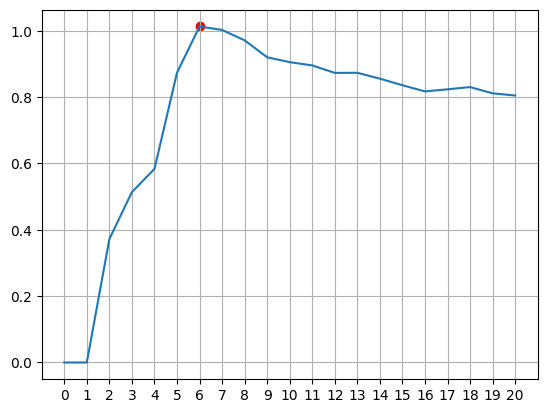

Оптимальное число класетров: 6


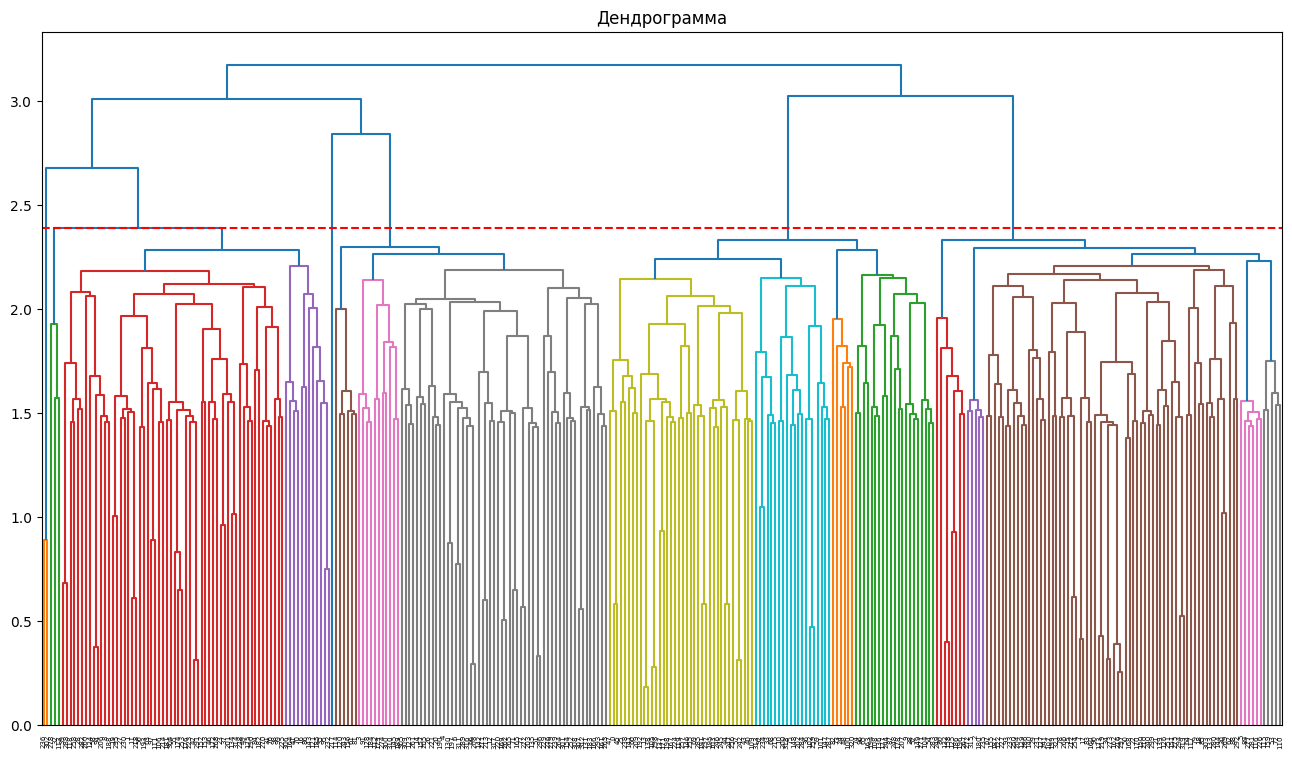

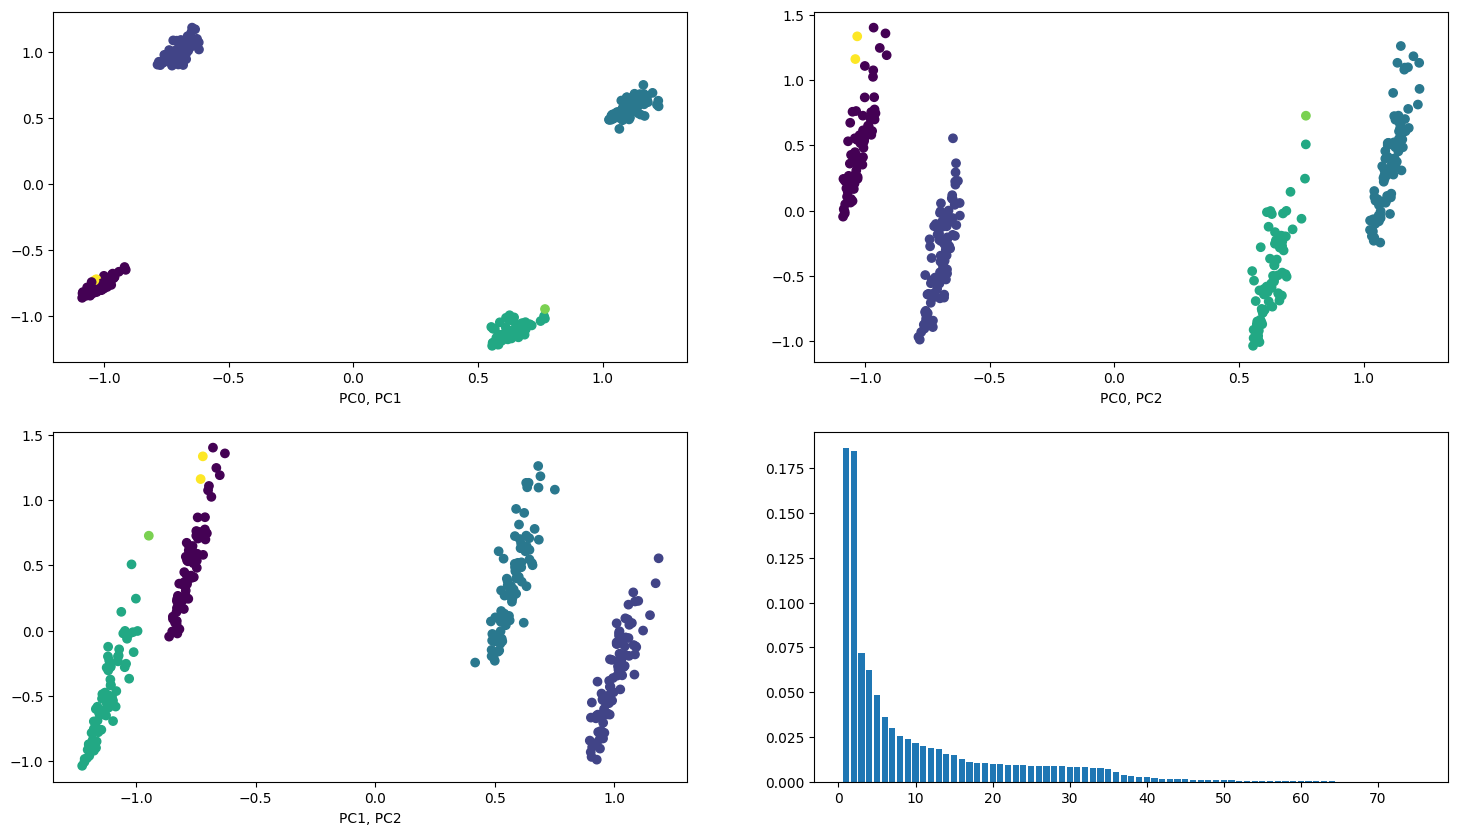

####################
EM-Алгоритм:


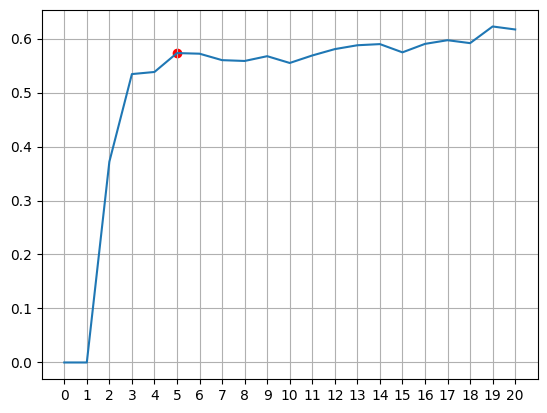

Оптимальное число класетров: 5


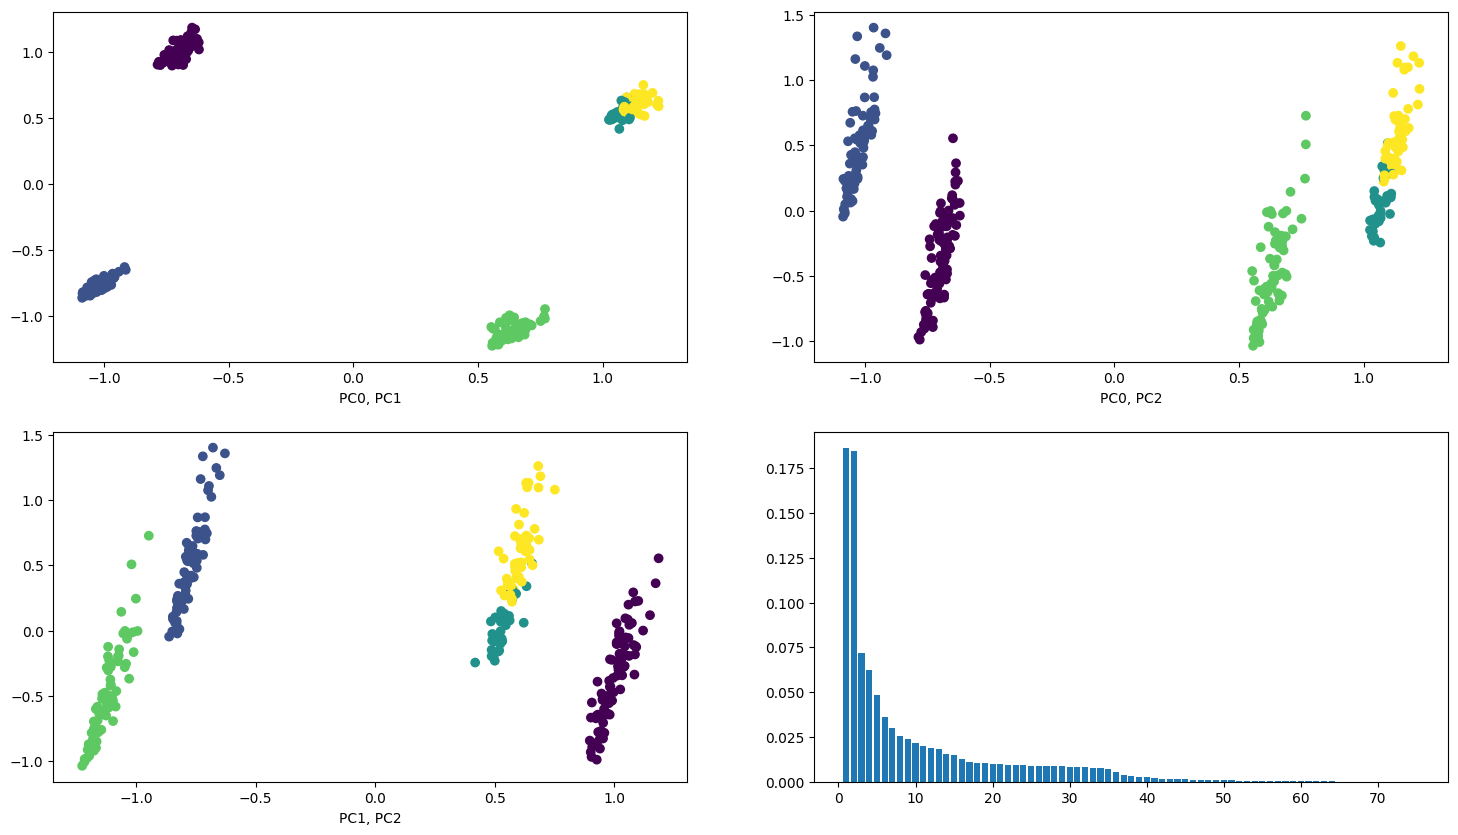

Лучшие представители своих кластеров:
Класс: 0 Представитель: Davis, Alan
Класс: 1 Представитель: Ashby, Alan
Класс: 2 Представитель: Allanson, Andy
Класс: 3 Представитель: Dawson, Andre
Класс: 4 Представитель: Thornton, Andre


In [17]:

start_data = pd.read_csv('baseball.csv')
data = start_data.drop(columns=['Name'])

data.Salary = KNNImputer(n_neighbors=5).fit_transform(data[['Salary']].values)
data.logSalary = np.log(1+data.Salary)
data.Salary, data.logSalary

def run_research(data, preproc=True):

    if preproc:
        data = preprocessing(data)
    
    print('Агломеративная модель:')
    best_h_k = pseudoF_plot(data, mode='hierarhy')
    print('Оптимальное число класетров:', best_h_k)
    dendrogram_building(data, best_h_k)
    AM_clust = hierarhy_clustering(data, k=best_h_k)
    pca_plot(data, AM_clust)

    print('#'*20)

    print('EM-Алгоритм:')
    best_s_k = pseudoF_plot(data, mode='statistic')
    print('Оптимальное число класетров:', best_s_k)
    GM_clust, GM_clust_proba = statistic_clustering(data, k=best_s_k, return_proba=True)
    pca_plot(data, GM_clust)
    print('Лучшие представители своих кластеров:')
    for c, human_ind in enumerate(np.argmax(GM_clust_proba, axis=0)):
        print(f'Класс: {c}', f'Представитель: {data_start.iloc[human_ind]['Name']}')

run_research(data)

### Задание 9. 
Произведите дополнительную предобработку набора данных, сделав распределения
переменных более симметричными. Для этого с помощью гисторамм или метода describe в
dataframe или метода skew найдите переменные с одной модой и тяжелым правым хвостом,
примените к ним преобразование log(1+x). Запустите функцию из шага 8. Как изменилось
число кластеров, проекции и лучшие представители. Как считаете, субъективное качество
кластеризации изменилось? Как и почему?

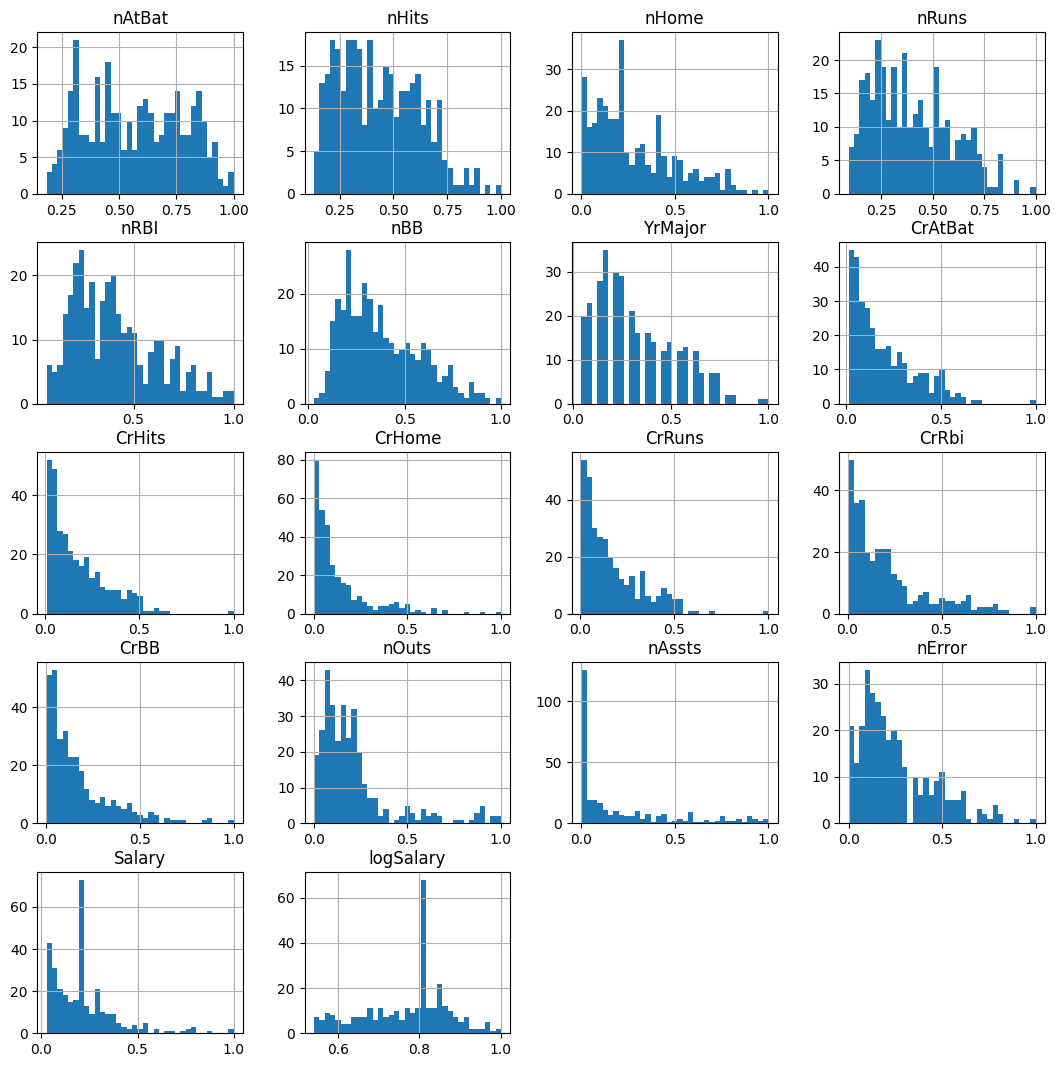

In [18]:
data = preprocessing(data)
data.loc[:, 'nAtBat':'logSalary'].hist(bins=35, figsize=(13, 13))
plt.show()

In [19]:
to_log = ['nHome', 'nRuns', 'nRBI', 'nBB', 'YrMajor',
       'CrAtBat', 'CrHits', 'CrHome', 'CrRuns', 'CrRbi', 'CrBB', 'nOuts',
       'nAssts', 'nError', 'Salary']
data[to_log] = np.log(1 + data[to_log])
data.head()

,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,CrHome,...,Position_OF,Position_OS,Position_RF,Position_S3,Position_SS,Position_UT,Div_AE,Div_AW,Div_NE,Div_NW
0,0.426492,0.277311,0.024693,0.207639,0.214845,0.125163,0.040822,0.020635,0.015389,0.001823,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.458515,0.340336,0.161268,0.169418,0.273114,0.315853,0.459532,0.219479,0.179145,0.118594,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.697234,0.546218,0.371564,0.410580,0.466900,0.544537,0.117783,0.109359,0.101995,0.108822,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.721980,0.592437,0.405465,0.405465,0.497514,0.301867,0.377294,0.336818,0.314859,0.344004,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.467249,0.365546,0.223144,0.262364,0.297960,0.251314,0.080043,0.027789,0.023454,0.021661,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Агломеративная модель:


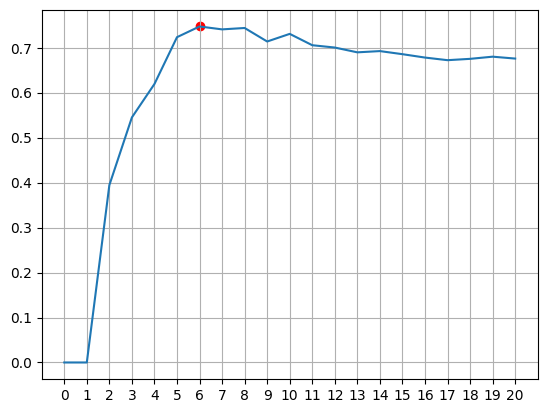

Оптимальное число класетров: 6


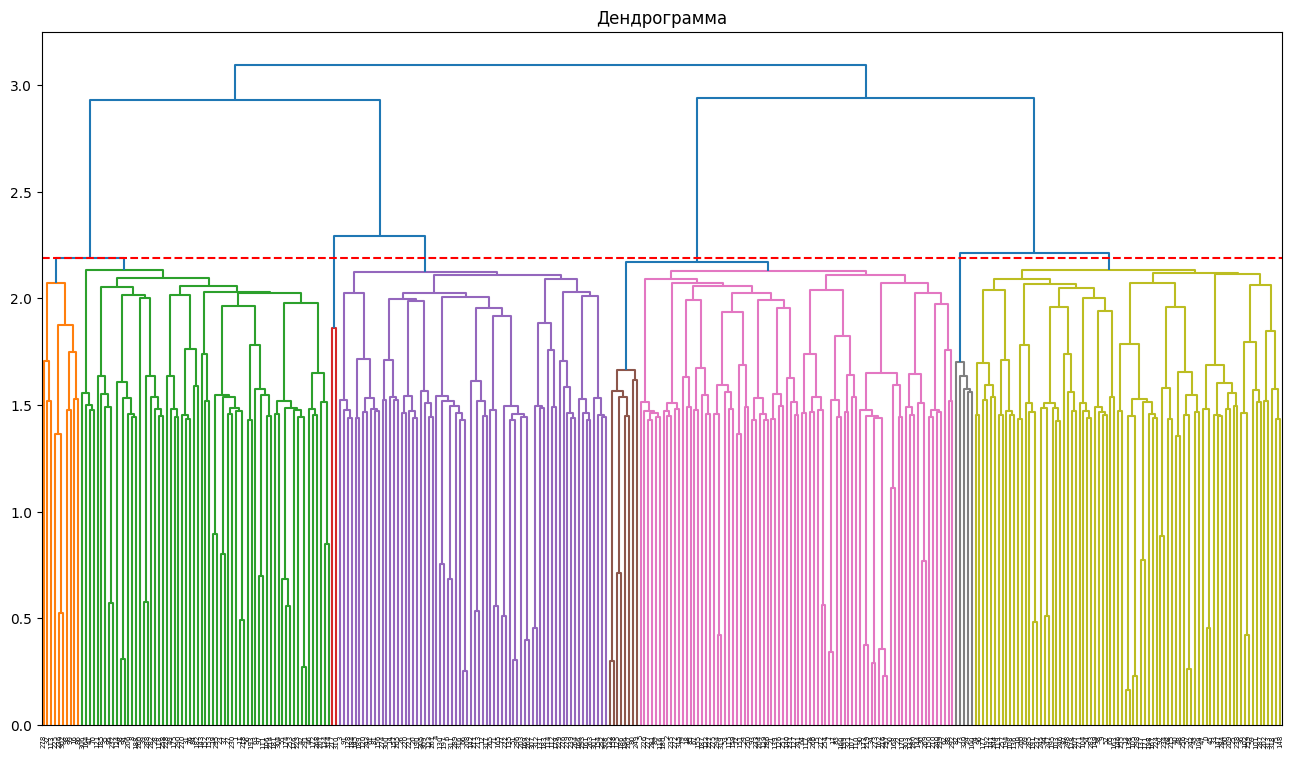

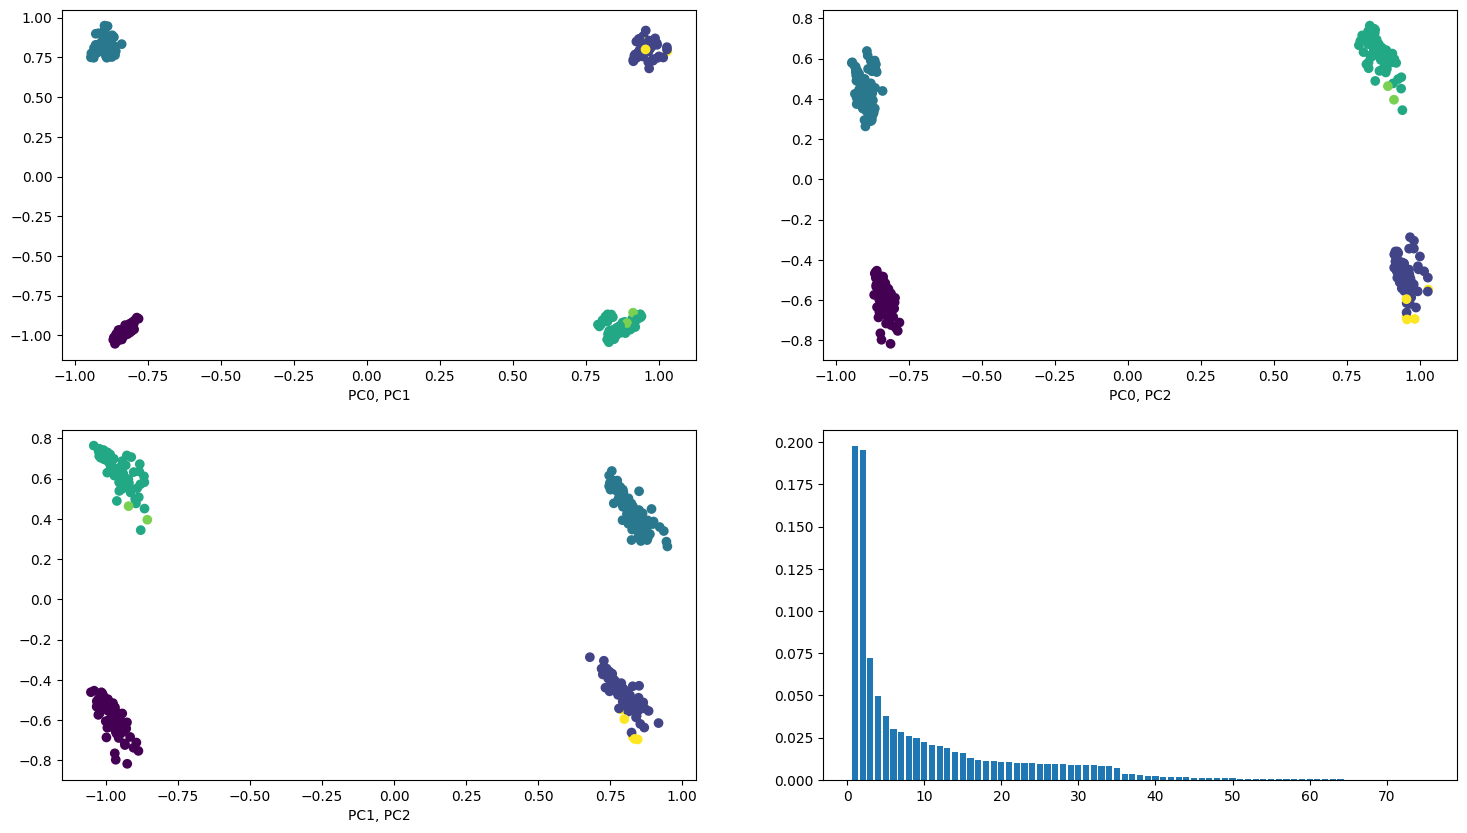

####################
EM-Алгоритм:


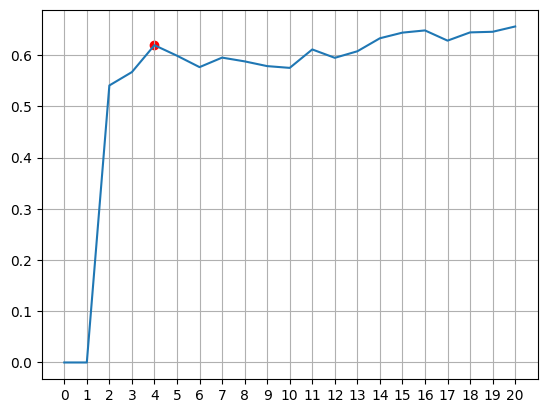

Оптимальное число класетров: 4


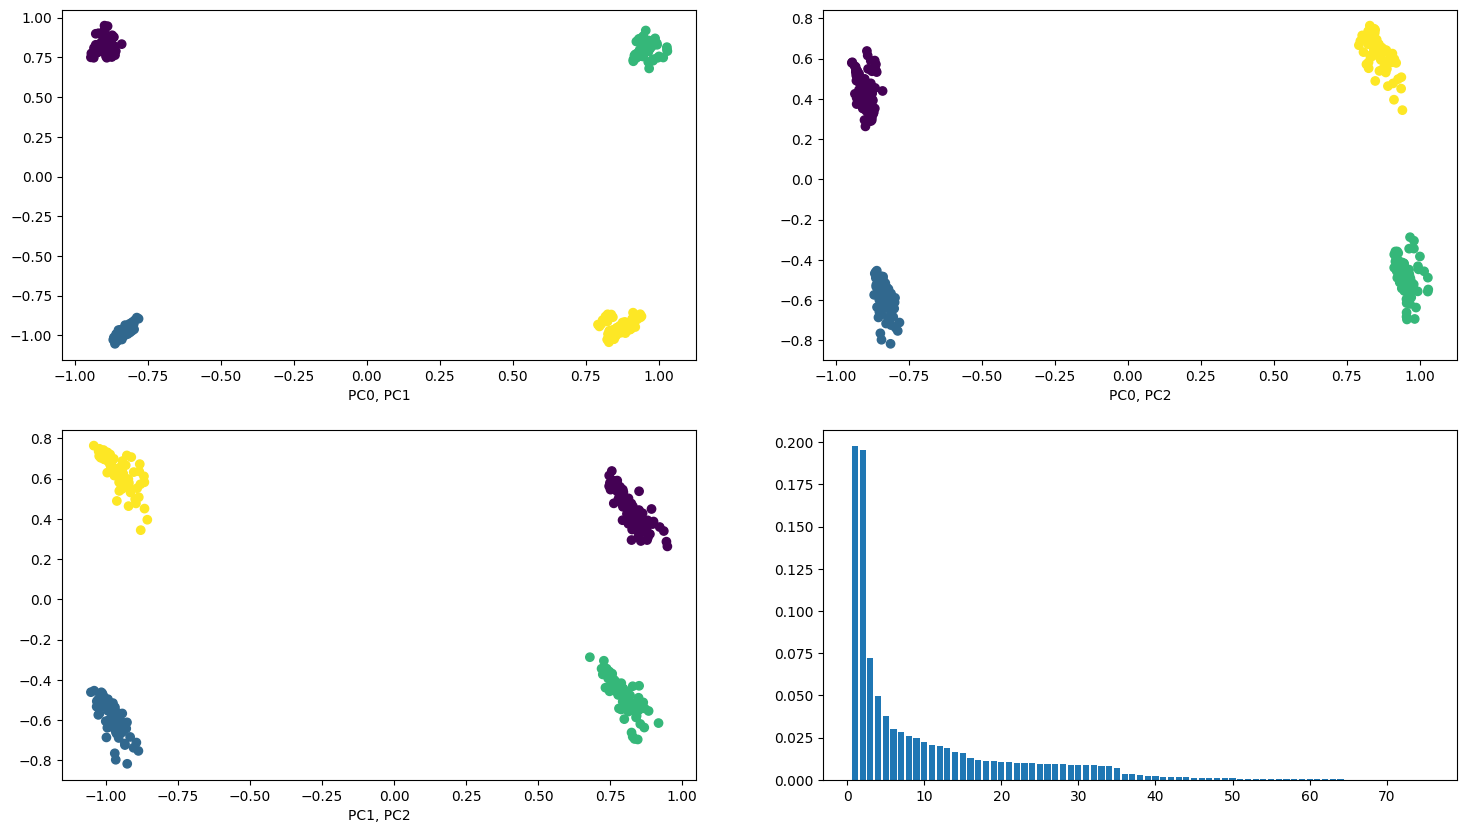

Лучшие представители своих кластеров:
Класс: 0 Представитель: Davis, Alan
Класс: 1 Представитель: Ashby, Alan
Класс: 2 Представитель: Allanson, Andy
Класс: 3 Представитель: Dawson, Andre


In [20]:
run_research(data, preproc=False)

### Задание 10. 
Отберите число наиболее значимых переменных из вашего варианта с помощью метода
VarClus. Запустите функцию из шага 8. Как изменилось число кластеров, проекции и лучшие
представители. Как считаете, субъективное качество кластеризации изменилось? Как и
почему?

In [21]:
clusters = VarClusHi(data, maxeigval2=0.8, maxclus=7)
clusters.varclus()
selected_columns = clusters.rsquare.groupby('Cluster')['Variable'].first().values

display(clusters.rsquare, clusters.info)
print(selected_columns)

,Cluster,Variable,RS_Own,RS_NC,RS_Ratio
0,0,YrMajor,0.812845,0.007686,0.188605
1,0,CrAtBat,0.945871,0.058116,0.057469
2,0,CrHits,0.940336,0.067534,0.063985
3,0,CrHome,0.770669,0.124833,0.262043
4,0,CrRuns,0.952187,0.090371,0.052563
...,...,...,...,...,...
70,5,Position_1O,0.019463,0.005456,0.985915
71,5,Position_S3,0.019457,0.009962,0.990410
72,5,Div_NW,0.751184,0.246406,0.330173
73,6,nOuts,0.854871,0.108180,0.162733


,Cluster,N_Vars,Eigval1,Eigval2,VarProp
0,0,18,7.351020,1.298024,0.408390
1,1,14,4.898580,1.274919,0.349899
2,2,11,3.059174,1.272080,0.278107
3,3,7,2.307641,1.171315,0.329663
4,4,13,2.195875,1.312040,0.168913
5,5,10,3.002787,1.316270,0.300279
6,6,2,1.709743,0.290257,0.854871


['YrMajor' 'nAtBat' 'Team_Baltimore' 'nAssts' 'Team_California'
 'Team_Atlanta' 'nOuts']


Агломеративная модель:


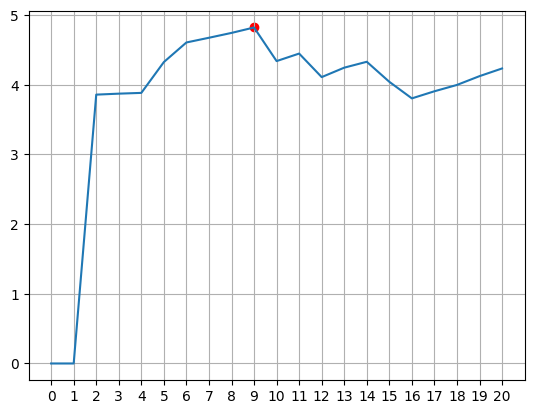

Оптимальное число класетров: 9


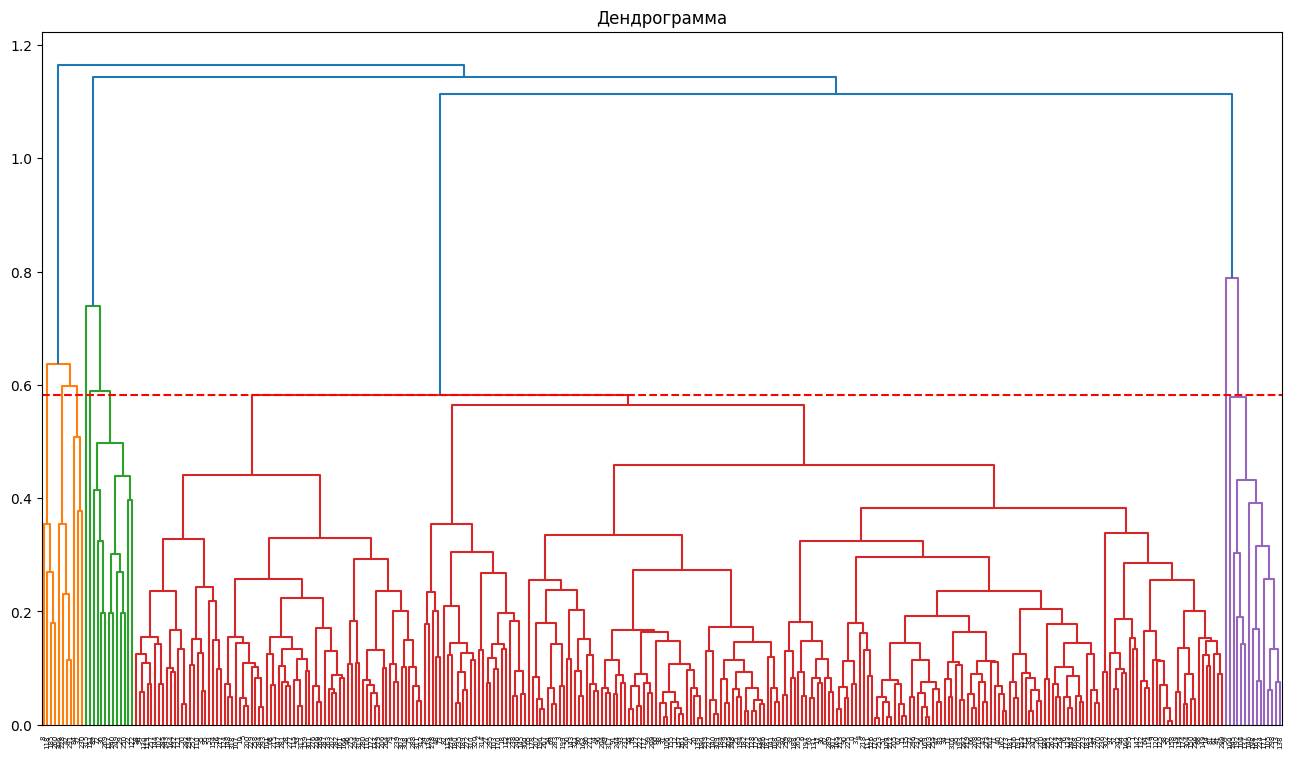

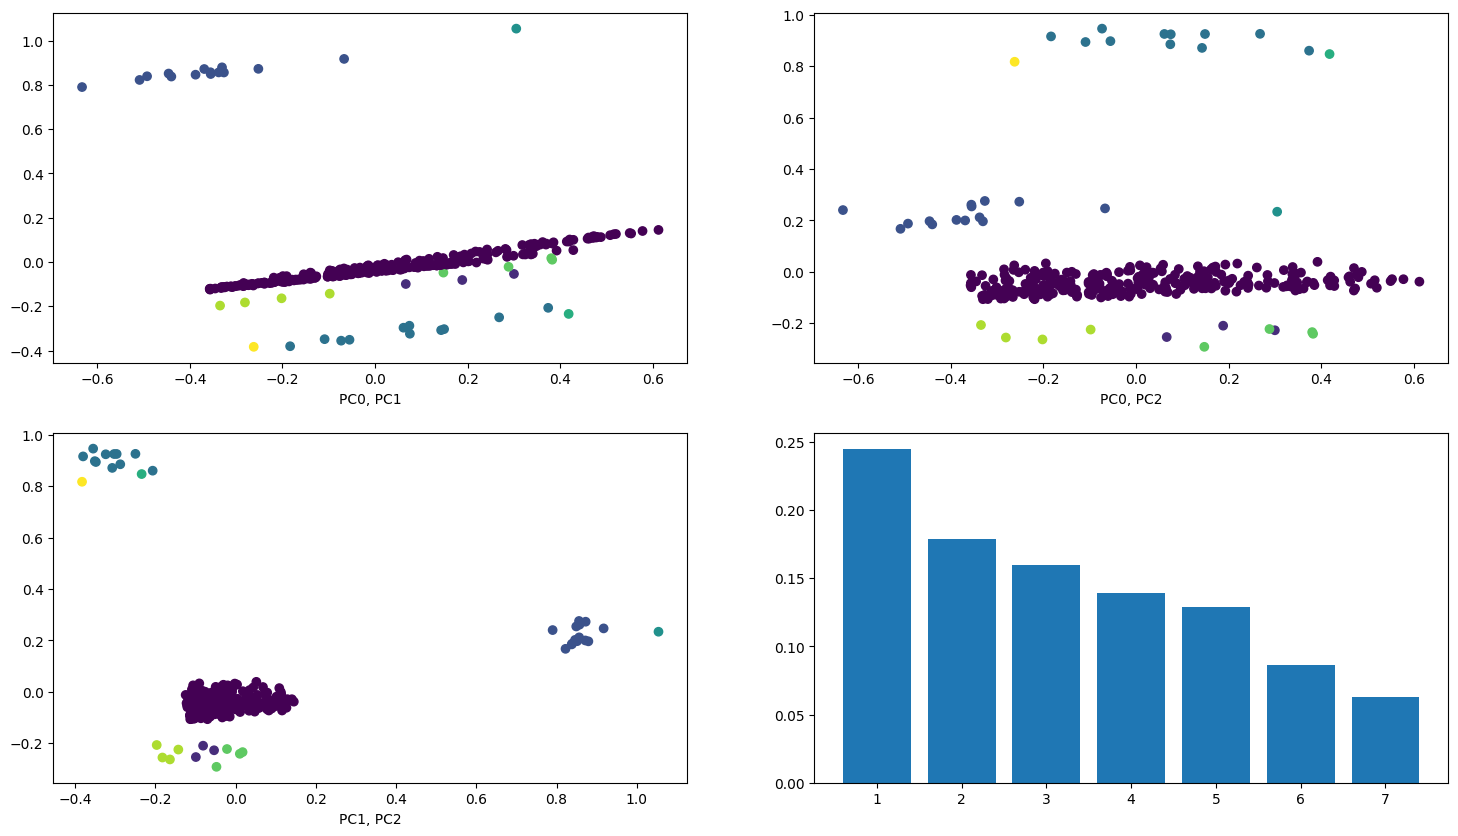

####################
EM-Алгоритм:


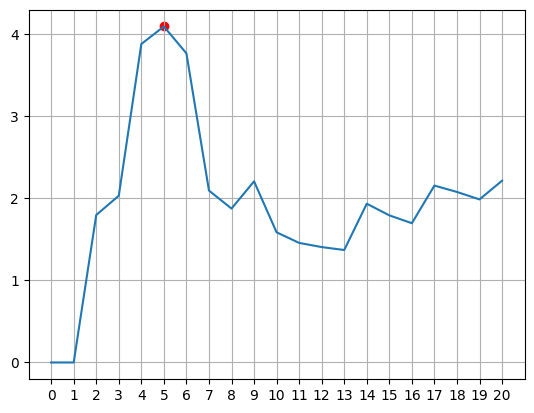

Оптимальное число класетров: 5


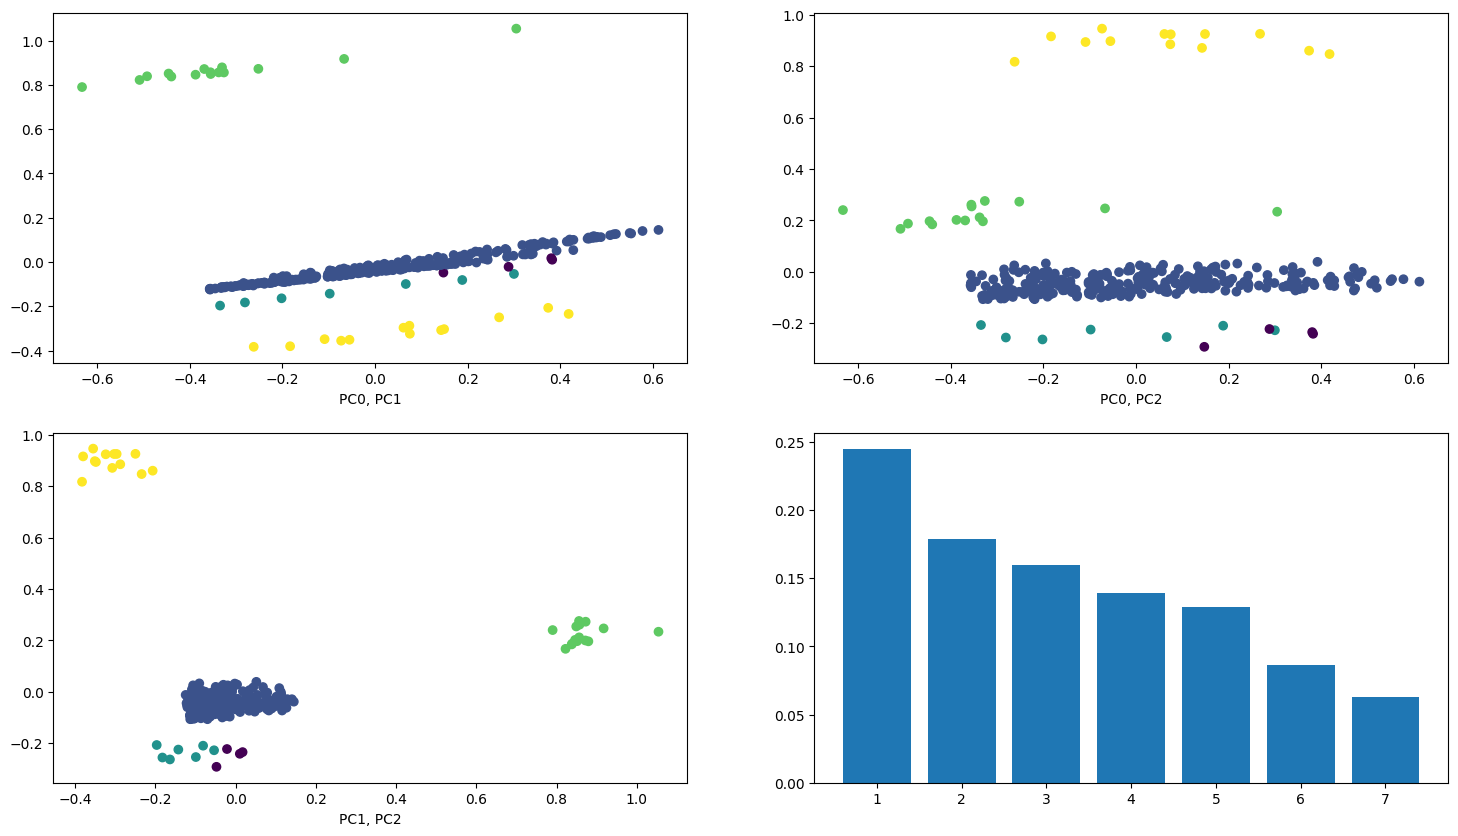

Лучшие представители своих кластеров:
Класс: 0 Представитель: Thomas, Andres
Класс: 1 Представитель: Allanson, Andy
Класс: 2 Представитель: Horner, Bob
Класс: 3 Представитель: Wiggins, Alan
Класс: 4 Представитель: Boone, Bob


In [22]:
run_research(data[selected_columns], preproc=False)

### Задание 11. 
«Творческое задание» на поиск аномалий. Загрузите файл mnist_small.csv. Данный набор
данных содержит подмножество эталонного набора данных рукописных цифр MNIST. 5923
картинок 28x28 пикселей с изображением нуля и 76 картинок с изображением шестерки.
Задача состоит в том, чтобы с использованием методов обучения без учителя для своего
варианта построить одноклассовую модель на основе поиска аномалий, которая максимально
хорошо отфильтрует шестерки (как аномалии) от нулей (как основной выборки). Признаки
картинок описываются их координатами (в названии переменных, например «10x12») и
значением яркости точки по этим координатам. Подбирая параметры метода и преобразуя
признаки как посчитаете нужным, но не используя при этом информацию о label, постройте
модель выявления аномалий с ERR EER (Equal Error Rate) меньше 0.2.

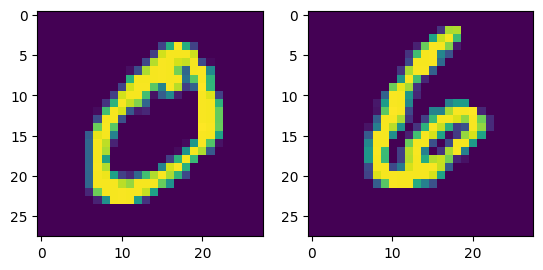

In [30]:
_, axs = plt.subplots(1, 2)
mnist = pd.read_csv('mnist_small.csv')

for i, m in enumerate(mnist.groupby('label').first().values):
    axs[i].imshow(m.reshape(28, 28))

mnist_bald = mnist.drop(columns=['label'])
mnist_bald = preprocessing(mnist_bald)

labels = mnist['label'].values

zeros = mnist_bald[labels==0]

> Попробую: 50 компонент + rbf + индекс жаккарда

In [31]:
kpca = KernelPCA(n_components=50, kernel='rbf', fit_inverse_transform=True)
kpca.fit(zeros)

KernelPCA(fit_inverse_transform=True, kernel='rbf', n_components=50)

In [32]:
def jaccard_index(img1, img2):
    intersection = np.logical_and(img1, img2).sum()
    union = np.logical_or(img1, img2).sum()
    return intersection / union if union != 0 else 0.0

kpca_mnist_bald = kpca.transform(mnist_bald)
error_mnist_bald = []
for i in range(len(mnist_bald)):
    error_mnist_bald.append(
        jaccard_index(
            mnist_bald.iloc[i]>0.5,
            (kpca.inverse_transform(kpca_mnist_bald[i:i+1])>0.5).reshape(-1)
        )
    )
error_mnist_bald = np.array(error_mnist_bald)

In [33]:
threshold = pd.DataFrame(error_mnist_bald).quantile(0.05)[0]
threshold

0.29311411163160955

In [34]:
anom_kpca_mnist_bald = kpca_mnist_bald[(error_mnist_bald < threshold) & (labels==6)]
print(anom_kpca_mnist_bald.shape[0], 'из', (labels==6).sum(), 'шестерок найдено')

26 из 76 шестерок найдено


> Видим, что модель справилась плохо, тогда попробую: 50 компонент + cosine + MSE

cosine выбираю из размышлений о том, что он опирается только на угол между векторами признаков, т.е. сами значения пикселей(яркость пикселей) ему не интересны, а нам как раз и нужно отличать в первую очередь форму цифры.

In [35]:
kpca = KernelPCA(n_components=50, kernel='cosine', fit_inverse_transform=True)
kpca.fit(zeros)

KernelPCA(fit_inverse_transform=True, kernel='cosine', n_components=50)

In [36]:
kpca_mnist_bald = kpca.transform(mnist_bald)
error_mnist_bald = np.mean((mnist_bald - kpca.inverse_transform(kpca_mnist_bald))**2, axis=1)

threshold = pd.DataFrame(error_mnist_bald).quantile(0.95)[0]
threshold

0.1299978873101161

In [37]:
anom_kpca_mnist_bald = kpca_mnist_bald[(error_mnist_bald > threshold) & (labels==6)]
print(anom_kpca_mnist_bald.shape[0], 'из', (labels==6).sum(), 'шестерок найдено')

65 из 76 шестерок найдено


### Задание 12. 
Постройте ROC кривую с ERR EER. Выведите 4 картинки с числами (28 на 28 пикселей):<br>
o самый типичный “0” – true negative с минимальной аномальностью<br>
o самая аномальная “6” – true positive с максимальной аномальностью<br>
o самый нетипичный “0” – false positive с максимальной аномальностью<br>
o самая неаномальная “6” – false negative с минимальной аномальностью

In [64]:
fpr, tpr, thresholds = roc_curve((labels==6).astype(int), error_mnist_bald)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC: {roc_auc}")

ROC-AUC: 0.9775073975670224


> Напоминалка: tpr - способность распознавать ЕДИНИЦЫ, fpr - НЕспособность распознавать НУЛИ

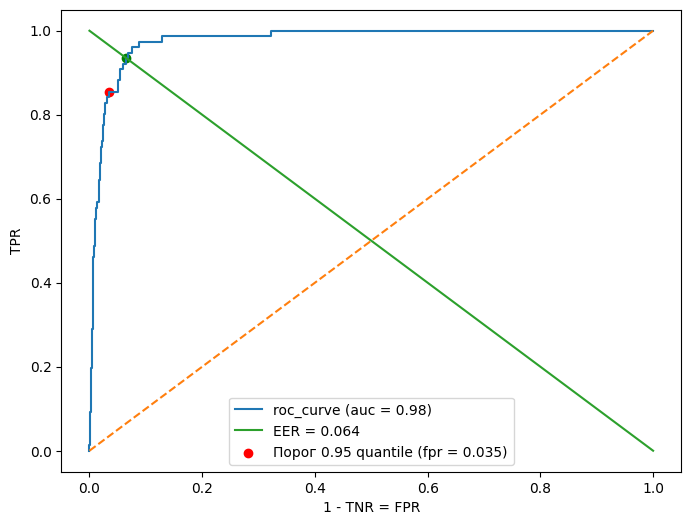

In [113]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'roc_curve (auc = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')

EER_ind = np.argmin(abs(tpr + fpr - 1))
EER = fpr[EER_ind]
plt.plot([1, 0], [0, 1], label=f'EER = {EER:.3}')
plt.scatter(fpr[EER_ind], tpr[EER_ind], c='g')

plt.xlabel('1 - TNR = FPR')
plt.ylabel('TPR')

# 0.95 квантиль
my_threshold_ind = np.argmin(np.abs(thresholds - threshold))
plt.scatter(fpr[my_threshold_ind], tpr[my_threshold_ind], 
            color='red', label=f'Порог 0.95 quantile (fpr = {fpr[my_threshold_ind]:.2})')
plt.legend()
plt.show()

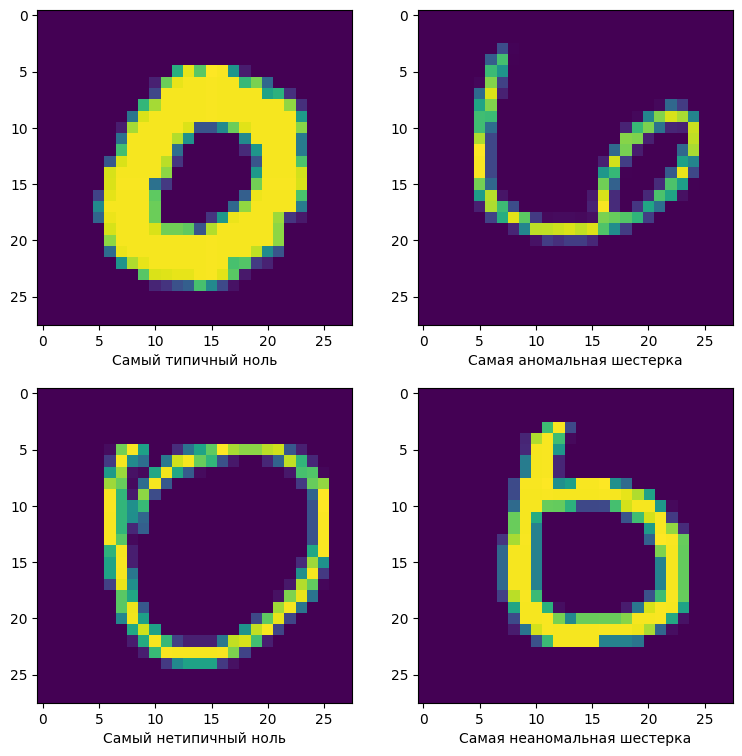

In [128]:
_, axs = plt.subplots(2, 2, figsize=(9, 9))


TN = mnist_bald[(labels == 0) & (error_mnist_bald == error_mnist_bald[(labels == 0)].min())]
axs[0][0].imshow(TN.to_numpy().reshape(28, 28))
axs[0][0].set_xlabel('Самый типичный ноль')


TP = mnist_bald[(labels == 6) & (error_mnist_bald == error_mnist_bald[(labels == 6)].max())]
axs[0][1].imshow(TP.to_numpy().reshape(28, 28))
axs[0][1].set_xlabel('Самая аномальная шестерка')


FP = mnist_bald[(labels == 0) & (error_mnist_bald == error_mnist_bald[(labels == 0)].max())]
axs[1][0].imshow(FP.to_numpy().reshape(28, 28))
axs[1][0].set_xlabel('Самый нетипичный ноль')


FN = mnist_bald[(labels == 6) & (error_mnist_bald == error_mnist_bald[(labels == 6)].min())]
axs[1][1].imshow(FN.to_numpy().reshape(28, 28))
axs[1][1].set_xlabel('Самая неаномальная шестерка')

plt.show()